# Amazon Fashion Recommendation: Comprehensive Academic CF Baseline

This notebook mirrors traditional explicit recommendation workflows for educational/portfolio purposes and documents why these techniques break at production scale.


Modeled after the structure of the prototype notebook (`Amazon Recommendation System Prototype.ipynb`) with added critical commentary for large-scale deployment constraints.


In [1]:
# Run if needed:
%pip install scikit-surprise matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

SURPRISE_OK = True
SURPRISE_IMPORT_ERROR = None
try:
    from surprise import Dataset, Reader, SVD, KNNWithMeans, accuracy
    from surprise.model_selection import train_test_split, GridSearchCV
except Exception as e:
    SURPRISE_OK = False
    SURPRISE_IMPORT_ERROR = e
    print("scikit-surprise import failed.")
    print(e)
    print("\nLikely cause: NumPy ABI mismatch (e.g., NumPy 2.x with surprise built for NumPy 1.x).")
    print("Fix in your notebook terminal, then restart kernel:")
    print("pip install --upgrade --force-reinstall \"numpy<2\" \"scikit-surprise==1.1.4\"")


In [3]:
@dataclass
class Config:
    train_path: str = "mini_train.csv"
    test_path: str = "mini_test.csv"
    file_format: str = "csv"

    user_col: str = "user_id"
    item_col: str = "parent_asin"
    rating_col: str = "rating"

    rating_scale: Tuple[int, int] = (1, 5)
    min_ratings_filter: int = 5  # practical for this 250K educational dataset
    academic_reference_filter: int = 50  # common in papers on larger datasets
    random_state: int = 42

cfg = Config()
cfg


Config(train_path='mini_train.csv', test_path='mini_test.csv', file_format='csv', user_col='user_id', item_col='parent_asin', rating_col='rating', rating_scale=(1, 5), min_ratings_filter=5, academic_reference_filter=50, random_state=42)

In [4]:
def resolve_data_path(path: str) -> Path:
    raw = Path(path).expanduser()
    if raw.is_absolute() and raw.exists():
        return raw

    cwd = Path.cwd()
    candidates = [
        cwd / raw,
        cwd / raw.name,
        cwd / "research" / raw,
        cwd / "research" / raw.name,
    ]
    for parent in cwd.parents:
        candidates.extend([
            parent / raw,
            parent / raw.name,
            parent / "research" / raw,
            parent / "research" / raw.name,
        ])

    seen = set()
    deduped = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            deduped.append(c)

    for c in deduped:
        if c.exists():
            return c

    tried = "\n".join(f"- {c}" for c in deduped[:12])
    raise FileNotFoundError(
        f"Could not find file {path!r}.\n"
        f"Working dir: {cwd}\n"
        f"Checked:\n{tried}"
    )


def read_df(path: str, fmt: str = "csv") -> pd.DataFrame:
    resolved = resolve_data_path(path)
    if fmt == "csv":
        return pd.read_csv(resolved)
    if fmt == "parquet":
        return pd.read_parquet(resolved)
    raise ValueError("fmt must be csv/parquet")


def prepare(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    cols = [cfg.user_col, cfg.item_col, cfg.rating_col]
    out = df[cols].copy()
    out[cfg.rating_col] = pd.to_numeric(out[cfg.rating_col], errors="coerce")
    out = out.dropna(subset=cols)
    out = out.drop_duplicates(subset=[cfg.user_col, cfg.item_col], keep="last")
    return out


def matrix_density(df: pd.DataFrame, user_col: str, item_col: str) -> float:
    observed = len(df)
    possible = df[user_col].nunique() * df[item_col].nunique()
    return observed / possible if possible else 0.0


def format_pct(x: float) -> str:
    return f"{100*x:.6f}%"


def estimate_dense_similarity_gb(n_entities: int, dtype_bytes: int = 4) -> float:
    return (n_entities ** 2) * dtype_bytes / (1024 ** 3)


def recommend_popular(pop_df: pd.DataFrame, top_n: int = 5, user_id: str | None = None) -> pd.DataFrame:
    recs = pop_df.head(top_n).copy()
    if user_id is not None:
        recs.insert(0, "user_id", user_id)
    return recs


def ensure_surprise() -> None:
    if not SURPRISE_OK:
        raise RuntimeError(
            "scikit-surprise is unavailable due to binary incompatibility. "
            "Run: pip install --upgrade --force-reinstall \"numpy<2\" \"scikit-surprise==1.1.4\" "
            "then restart the Jupyter kernel."
        ) from SURPRISE_IMPORT_ERROR


In [5]:
train_raw = read_df(cfg.train_path, cfg.file_format)
test_raw = read_df(cfg.test_path, cfg.file_format)

train_df = prepare(train_raw, cfg)
test_df = prepare(test_raw, cfg)

combined_df = pd.concat([train_df, test_df], ignore_index=True)

print("Train shape   :", train_df.shape)
print("Test shape    :", test_df.shape)
print("Combined shape:", combined_df.shape)
display(combined_df.head())


Train shape   : (250000, 3)
Test shape    : (20282, 3)
Combined shape: (270282, 3)


,user_id,parent_asin,rating
0,AGTQVJKZR5MFMT75CBTM6BKUBGJQ,B006455HKI,5.0
1,AFF5RQJVDUQENXFOFMPN3MCXARFA,B005GCCJJW,4.0
2,AFMPVZ7WMJVPGSICTHHYIODNNABQ,B008R6PKBS,5.0
3,AF2YT7L5ZDIT4V57RZ2XTY7SAPNQ,B0C15H1PGM,2.0
4,AF6CO6WVKTOV7LG5ODL4CMJGSY4Q,B005033D0Q,4.0


## 1. Exploratory Data Analysis (EDA)

We check missingness and visualize rating distribution using both bar and pie charts.


Missing values by column:


user_id        0
parent_asin    0
rating         0
dtype: int64

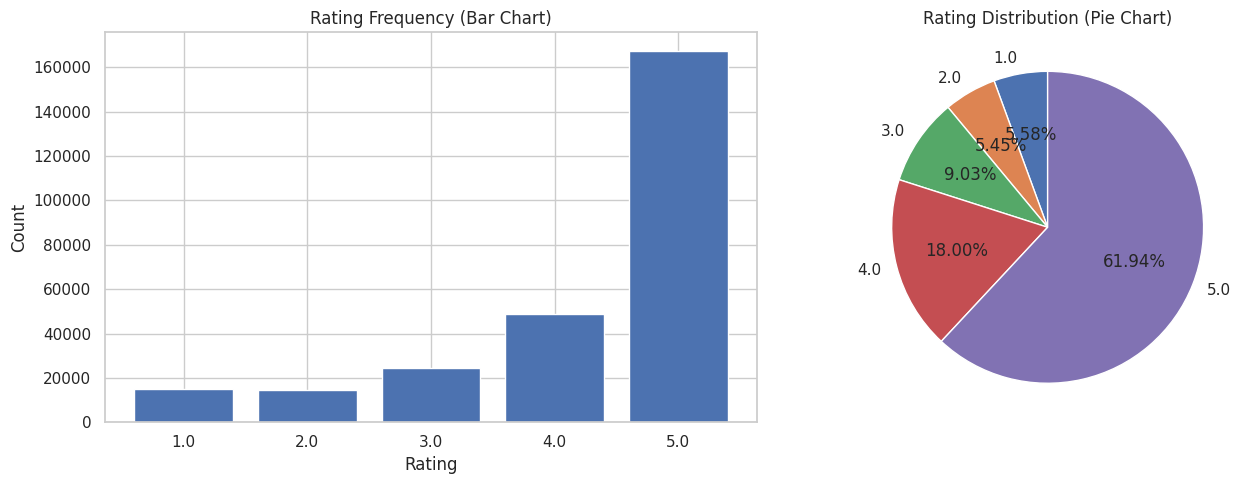

,count,percent
rating,,
1.0,15083,5.580
2.0,14731,5.450
3.0,24409,9.031
4.0,48639,17.996
5.0,167420,61.943


In [6]:
missing_summary = combined_df.isna().sum()
print("Missing values by column:")
display(missing_summary)

rating_counts = combined_df[cfg.rating_col].value_counts().sort_index()
rating_pct = (rating_counts / rating_counts.sum()) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(rating_counts.index.astype(str), rating_counts.values)
ax[0].set_title("Rating Frequency (Bar Chart)")
ax[0].set_xlabel("Rating")
ax[0].set_ylabel("Count")

ax[1].pie(rating_counts.values, labels=rating_counts.index.astype(str), autopct="%1.2f%%", startangle=90)
ax[1].set_title("Rating Distribution (Pie Chart)")

plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": rating_counts, "percent": rating_pct.round(3)}))


## 2. Sparsity & Academic Filtering

We compute exact user-item density before/after filtering by minimum ratings.

- For this small educational dataset (~250K rows), we use **min ratings = 5** for modeling.
- We also report what happens at the academic reference value **50**.

**Interpretation to keep in mind:**
- On this smaller dataset, a threshold of 5 is not very harmful and can be a practical denoising step.
- On million-scale datasets, threshold 50 is common academically but can truncate huge tail populations, making it a poor industry default.


In [7]:
density_before = matrix_density(combined_df, cfg.user_col, cfg.item_col)
n_rows_total = len(combined_df)
n_users_total = combined_df[cfg.user_col].nunique()
n_items_total = combined_df[cfg.item_col].nunique()

print(f"Density before filtering: {density_before:.12f} ({format_pct(density_before)})")
print(f"Total rows/users/items: {n_rows_total:,} / {n_users_total:,} / {n_items_total:,}")

user_counts = combined_df[cfg.user_col].value_counts()

# Practical filter for this micro dataset
users_ge_min = user_counts[user_counts >= cfg.min_ratings_filter].index
filtered_min_df = combined_df[combined_df[cfg.user_col].isin(users_ge_min)].copy()
density_after_min = matrix_density(filtered_min_df, cfg.user_col, cfg.item_col)

rows_kept_min = len(filtered_min_df)
rows_truncated_min = n_rows_total - rows_kept_min
rows_truncated_min_pct = (rows_truncated_min / n_rows_total) * 100 if n_rows_total else 0.0

users_kept_min = filtered_min_df[cfg.user_col].nunique()
users_truncated_min = n_users_total - users_kept_min
users_truncated_min_pct = (users_truncated_min / n_users_total) * 100 if n_users_total else 0.0

print("\n--- Using min ratings =", cfg.min_ratings_filter, "---")
print(f"Rows kept: {rows_kept_min:,} | Rows truncated: {rows_truncated_min:,} ({rows_truncated_min_pct:.2f}%)")
print(f"Users kept: {users_kept_min:,} | Users truncated: {users_truncated_min:,} ({users_truncated_min_pct:.2f}%)")
print(f"Density after min={cfg.min_ratings_filter}: {density_after_min:.12f} ({format_pct(density_after_min)})")

# Academic reference threshold (for explanation)
users_ge_50 = user_counts[user_counts >= cfg.academic_reference_filter].index
filtered_50_df = combined_df[combined_df[cfg.user_col].isin(users_ge_50)].copy()
density_after_50 = matrix_density(filtered_50_df, cfg.user_col, cfg.item_col)
rows_kept_50 = len(filtered_50_df)
rows_truncated_50 = n_rows_total - rows_kept_50
rows_truncated_50_pct = (rows_truncated_50 / n_rows_total) * 100 if n_rows_total else 0.0

print("\n--- Academic reference min ratings =", cfg.academic_reference_filter, "---")
print(f"Rows kept: {rows_kept_50:,} | Rows truncated: {rows_truncated_50:,} ({rows_truncated_50_pct:.2f}%)")
print(f"Density after min={cfg.academic_reference_filter}: {density_after_50:.12f} ({format_pct(density_after_50)})")
if rows_kept_50 == 0:
    print("At this micro scale, threshold 50 removes everything. In million-scale datasets, it still truncates huge long-tail segments.")

# modeling dataframe for all following sections
modeling_df = filtered_min_df.copy()
print("\nModeling rows/users/items:", len(modeling_df), modeling_df[cfg.user_col].nunique(), modeling_df[cfg.item_col].nunique())


Density before filtering: 0.000009123926 (0.000912%)
Total rows/users/items: 270,282 / 225,239 / 131,520

--- Using min ratings = 5 ---
Rows kept: 7,702 | Rows truncated: 262,580 (97.15%)
Users kept: 1,206 | Users truncated: 224,033 (99.46%)
Density after min=5: 0.000978458913 (0.097846%)

--- Academic reference min ratings = 50 ---
Rows kept: 0 | Rows truncated: 270,282 (100.00%)
Density after min=50: 0.000000000000 (0.000000%)
At this micro scale, threshold 50 removes everything. In million-scale datasets, it still truncates huge long-tail segments.

Modeling rows/users/items: 7702 1206 6527


## 3. Train/Test Split

As requested, we combine datasets first and split filtered data into 70:30 using `surprise.model_selection.train_test_split`.

For this notebook run, filtered data = users with at least 5 ratings (practical micro-scale threshold).


In [8]:
ensure_surprise()
reader = Reader(rating_scale=cfg.rating_scale)
surprise_data = Dataset.load_from_df(modeling_df[[cfg.user_col, cfg.item_col, cfg.rating_col]], reader)
trainset, testset = train_test_split(surprise_data, test_size=0.3, random_state=cfg.random_state)

print("Surprise trainset users/items/ratings:", trainset.n_users, trainset.n_items, trainset.n_ratings)
print("Surprise testset size:", len(testset))


Surprise trainset users/items/ratings: 1205 4705 5391
Surprise testset size: 2311


## 4. Popularity Baseline

Non-personalized baseline: globally popular products by rating volume and average rating.


In [9]:
popularity_df = (
    modeling_df.groupby(cfg.item_col)
    .agg(rating_count=(cfg.rating_col, "count"), rating_mean=(cfg.rating_col, "mean"))
    .reset_index()
)
popularity_df["popularity_score"] = popularity_df["rating_count"] * popularity_df["rating_mean"]
popularity_df = popularity_df.sort_values(["rating_count", "rating_mean", "popularity_score"], ascending=False).reset_index(drop=True)

print("Top-10 popular products:")
display(popularity_df.head(10))


Top-10 popular products:


,parent_asin,rating_count,rating_mean,popularity_score
0,B07TVHSDMQ,124,4.548387,564.0
1,B07XFXXZMV,14,4.714286,66.0
2,B08513YB2T,14,4.428571,62.0
3,B0C54B89HH,14,3.714286,52.0
4,B0979ZS95M,11,4.909091,54.0
5,B08P4SSFX4,11,4.545455,50.0
6,B073H3GF9H,11,4.272727,47.0
7,B07T7RFKSR,11,4.090909,45.0
8,B0018OMK82,10,4.800000,48.0
9,B078GSXGWZ,10,4.400000,44.0


## 5. User-User Collaborative Filtering (KNNWithMeans, user_based=True)

We train User-User KNNWithMeans and evaluate with RMSE/MAE.

**OOM warning at scale:** User-user similarity is roughly an `n_users x n_users` structure, which is quadratic in user count.


In [10]:
n_users_full = combined_df[cfg.user_col].nunique()
user_user_gb = estimate_dense_similarity_gb(n_users_full, dtype_bytes=4)
print(f"Unique users in combined data: {n_users_full:,}")
print(f"Approx dense user-user matrix memory (float32): {user_user_gb:,.2f} GB")


Unique users in combined data: 225,239
Approx dense user-user matrix memory (float32): 188.99 GB


In [11]:
sim_user = {"name": "cosine", "user_based": True}
uu_model = KNNWithMeans(k=20, sim_options=sim_user, verbose=False)
uu_model.fit(trainset)
uu_preds = uu_model.test(testset)

uu_rmse = accuracy.rmse(uu_preds, verbose=False)
uu_mae = accuracy.mae(uu_preds, verbose=False)
print(f"User-User KNN RMSE: {uu_rmse:.4f}")
print(f"User-User KNN MAE : {uu_mae:.4f}")


User-User KNN RMSE: 1.1354
User-User KNN MAE : 0.8779


## 6. Item-Item Collaborative Filtering (KNNWithMeans, user_based=False)

We train Item-Item KNNWithMeans and evaluate with RMSE/MAE.

**OOM warning at scale:** Item-item similarity is roughly an `n_items x n_items` structure, also quadratic growth.


In [12]:
n_items_full = combined_df[cfg.item_col].nunique()
item_item_gb = estimate_dense_similarity_gb(n_items_full, dtype_bytes=4)
print(f"Unique items in combined data: {n_items_full:,}")
print(f"Approx dense item-item matrix memory (float32): {item_item_gb:,.2f} GB")


Unique items in combined data: 131,520
Approx dense item-item matrix memory (float32): 64.44 GB


In [13]:
sim_item = {"name": "cosine", "user_based": False}
ii_model = KNNWithMeans(k=20, sim_options=sim_item, verbose=False)
ii_model.fit(trainset)
ii_preds = ii_model.test(testset)

ii_rmse = accuracy.rmse(ii_preds, verbose=False)
ii_mae = accuracy.mae(ii_preds, verbose=False)
print(f"Item-Item KNN RMSE: {ii_rmse:.4f}")
print(f"Item-Item KNN MAE : {ii_mae:.4f}")


Item-Item KNN RMSE: 1.2125
Item-Item KNN MAE : 0.9290


## 7. Model-Based CF & Hyperparameter Tuning (SVD + GridSearchCV)

We tune SVD with GridSearchCV, train the best model, and evaluate with RMSE/MAE.

**Metric limitation note:** RMSE optimizes exact star prediction error, but modern e-commerce usually optimizes top-N ranking quality (e.g., NDCG).


In [14]:
param_grid = {
    "n_epochs": [10, 20],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1],
}

gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3, n_jobs=1)
gs.fit(surprise_data)

best_params = gs.best_params["rmse"]
print("Best params (RMSE):", best_params)
print("Best CV RMSE:", gs.best_score["rmse"])

svd_best = SVD(**best_params, random_state=cfg.random_state)
svd_best.fit(trainset)
svd_preds = svd_best.test(testset)

svd_rmse = accuracy.rmse(svd_preds, verbose=False)
svd_mae = accuracy.mae(svd_preds, verbose=False)
print(f"SVD RMSE: {svd_rmse:.4f}")
print(f"SVD MAE : {svd_mae:.4f}")


Best params (RMSE): {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02}
Best CV RMSE: 1.0884394859338031
SVD RMSE: 1.1004
SVD MAE : 0.8627


## 8. Qualitative User Comparison

Pick one user from the test set and compare:
- Top-5 Popularity recommendations (non-personalized)
- Top-5 SVD recommendations (personalized)


In [15]:
testset_df = pd.DataFrame(testset, columns=[cfg.user_col, cfg.item_col, cfg.rating_col])
target_user = testset_df[cfg.user_col].value_counts().idxmax()
print("Selected user_id:", target_user)

# Popularity top-5
pop_top5 = recommend_popular(popularity_df[[cfg.item_col, "rating_count", "rating_mean", "popularity_score"]], top_n=5, user_id=target_user)
print("\nTop-5 Popularity Recommendations:")
display(pop_top5)

# SVD top-5 personalized
all_items = modeling_df[cfg.item_col].unique()
seen_items = set(modeling_df.loc[modeling_df[cfg.user_col] == target_user, cfg.item_col])
candidate_items = [iid for iid in all_items if iid not in seen_items]

svd_scores = []
for iid in candidate_items:
    est = svd_best.predict(target_user, iid).est
    svd_scores.append((iid, est))

svd_top5 = pd.DataFrame(sorted(svd_scores, key=lambda x: x[1], reverse=True)[:5], columns=[cfg.item_col, "predicted_rating"])
svd_top5.insert(0, cfg.user_col, target_user)

print("Top-5 SVD Recommendations:")
display(svd_top5)


Selected user_id: AGCL74N5BZXULQCNUNDCNRNNCWSQ

Top-5 Popularity Recommendations:


,user_id,parent_asin,rating_count,rating_mean,popularity_score
0,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B07TVHSDMQ,124,4.548387,564.0
1,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B07XFXXZMV,14,4.714286,66.0
2,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B08513YB2T,14,4.428571,62.0
3,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B0C54B89HH,14,3.714286,52.0
4,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B0979ZS95M,11,4.909091,54.0


Top-5 SVD Recommendations:


,user_id,parent_asin,predicted_rating
0,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B0C65TFM9F,4.978778
1,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B004AXYX4M,4.957368
2,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B093XKHJGC,4.957262
3,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B07J322K95,4.916588
4,AGCL74N5BZXULQCNUNDCNRNNCWSQ,B08FM61LV6,4.915014


## Educational Conclusions

1. In this 250K-row teaching dataset, `min ratings = 5` is a practical compromise: it denoises while still keeping enough signal to run classical models.
2. In million-scale academic setups, `min ratings = 50` is a common preprocessing choice, but it can truncate massive long-tail behavior and discard large volumes of useful interactions.
3. User-User and Item-Item KNN remain quadratic-memory methods; similarity matrix growth creates strong OOM risk at production scale.
4. RMSE/MAE are valid for explicit star prediction, but top-N ranking metrics (NDCG/Recall/HR) align better with real e-commerce recommendation objectives.
